# Climate metrics calculation
- input values are based on van Manen aCCFs and efficacies as in Table 1 of Dahlmann et al. (2025)
- trajectory data based on Thales optimiser: filed trajectory and contrail-optimised trajectory

## Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pycontrails import Fleet

In [ ]:
dff = pd.read_parquet("../paper_nox/data/dff.parquet")
fleetf = Fleet(data=dff)
print(f"Fleet contains {fleetf.n_flights} flights")
dfo = pd.read_parquet("../paper_nox/data/dfo.parquet")
fleeto = Fleet(data=dfo)
print(f"Fleet contains {fleeto.n_flights} flights")

In [ ]:
variant = "f"  # filed "f" or optimised "o"

if variant == "f":
    df = dff
elif variant == "o":
    df = dfo

In [ ]:
# update meta ID (to replace Thales ID with normal count)
meta = pd.read_parquet("~/sourcetree/jecats-paper-climate-mitigation/data/gufi/concerto_sol2_ex2_filed_meta.parquet")
id_to_index = pd.Series(meta.index, index=meta["flight_id"]).rename("id")
df["flight_id"] = df["flight_id"].map(id_to_index)

In [ ]:
# ============================================================
# Contrail aCCFs (Yin et al. 2023, Dietmüller et al. 2023)
# using the SAC output from CoCiP (Schumann 2012).
# When multiplied with 0.0151, then the output is in P-ATR20.
# ============================================================

def night_contrail_RF(temperature: np.ndarray, sdr: np.ndarray) -> np.ndarray:
    """
    Calculate the night contrail RF using the aCCF.
    :param temperature: Air temperature in [K]
    :param sdr: Solar direct radiation in [W / m^2]
    :return: Radiative forcing (RF) in [W / m^2]
    """
    RF = 1e-10 * (0.0073 * (10 ** (0.0107 * temperature)) - 1.03)  # Equation 6, Yin et al. 2023
    RF = np.where(temperature > 201, RF, 0)  # Temperature threshold
    RF = np.maximum(RF, 0)  # only positive (warming) values allowed
    RF = np.where(sdr <= 1, RF, 0)  # only nighttime
    return RF


def day_contrail_RF(olr_negative: np.ndarray, sdr: np.ndarray) -> np.ndarray:
    """
    Calculate the day contrail RF using the aCCF.
    :param olr_negative: Outgoing longwave radiation in [W / m^2]. Note: has to be negative!
    :param sdr: Solar direct radiation in [W / m^2]
    :return: Radiative forcing (RF) in [W / m^2]
    """
    RF = 1e-10 * (-1.7 - 0.0088 * olr_negative)  # Equation 8, Yin et al. 2023
    RF = np.where(sdr > 1, RF, 0)  # only daytime
    return RF


def contrail_RF(rf_night: np.ndarray, rf_day: np.ndarray, sac: np.ndarray) -> np.ndarray:
    """
    Calculate the contrail RF (day + night) using the aCCF.
    :param rf_night: Night contrail radiative forcing in [W / m^2]
    :param rf_day: Day contrail radiative forcing in [W / m^2]
    :param sac: Schmidt-Appleman criteria (SAC) as boolean
    :return: Radiative forcing (RF) in [W / m^2]
    """
    return np.where(sac == 1, rf_night + rf_day, 0)


def eagwp_from_contrail_ef(ef: float | np.ndarray[float], erf_rf_ratio: float = 1.0) -> float:
    """
        :param ef: EF in [J]
        :param erf_rf_ratio: ERF/RF or efficacy; e.g. 0.21 (Bickel 2025) or 0.42 (Lee 2021); default: 1.0 (then AGWP, not EAGWP)
        :return: (E)AGWP in [W m^-2 year]
    """
    return (ef / constants.surface_area_earth / constants.seconds_per_year) * erf_rf_ratio

## Configuration

In [ ]:
from src.metrics.metrics import Metrics, AGWP_CO2_100y, AGWP_CO2_20y
from src.utils.utils import mask_by_validity_range

### Configuration ###
# we use Matthes aCCF scaling factors
# we apply efficacies
# we run the calculation for 3 different metrics
# version v1 = Table 3 of Dahlmann et al. (2025), version v2 = table sent by Katrin in Email of July 7, 2026
## see the cell "Other" with the two for loops, printing all coefficients
# a Metrics() object has an attribute .cf (calibration factor), which is equivalent to the f_i->j factor in the paper

# aCCF version:
scaling = {
    "vanmanen_2019": {'CiC': 1, 'O3': 1, 'CH4': 1, 'H2O': 1},
    "yin_2023": {"CiC": 1, "O3": 1.97, "CH4": 2.03, "H2O": 1.92},
    "matthes_2025": {"CiC": 3, "O3": 11, "CH4": 35, "H2O": 3},
}
ver = "matthes_2025"
accf_bounds = [0, 1000]  #[150, 350], [0, 1000]
mask_cocip = False
efficacy = {
    "dahlmann_2025": {"CiC": 0.21, "O3": 1.05, "CH4": 1.04},
    "none": {"CiC": 1, "O3": 1, "CH4": 1},
}
eff = "dahlmann_2025"
target = "EAGWP20"  # EAGWP100, ATR100, EAGWP20
version = "v1"
m = Metrics(origin="RF", target=target, emission_scenario="pulse", version=version)
m2 = Metrics(origin="ATR20", target=target, emission_scenario="pulse", version=version)

calculate_co2eq = True

## Calculation

In [ ]:
from src.utils.utils import mask_by_marker

fleet = Fleet(data=df)

# Contrail aCCF
fleet["rf_day"] = day_contrail_RF(fleet["olr_mean"] * -1, fleet["sdr_mean"])  
fleet["rf_night"] = night_contrail_RF(fleet["air_temperature"], fleet["sdr_mean"])
fleet["rf_CiC"] = contrail_RF(fleet["rf_night"], fleet["rf_day"], fleet["sac"]) * efficacy[eff]["CiC"] / scaling[ver][
    "CiC"]
fleet.update({"rf_CiC": fleet["rf_CiC"] * fleet.segment_length() / 1e3})
mask_by_validity_range(fleet, ["rf_CiC"], bounds=accf_bounds)  # W m^-2 km^-1
fleet["CiC"] = fleet["rf_CiC"] * m.cf["CiC"]

# CoCiP
fleet["eagwp_cocip"] = eagwp_from_contrail_ef(fleet["ef"], efficacy[eff]["CiC"])
fleet["rf_cocip"] = fleet["eagwp_cocip"] / 0.21  # to get from EAGWP to RF, both for v1 and v2
if mask_cocip:
    mask_by_validity_range(fleet, ["rf_cocip"], bounds=accf_bounds)
fleet["CoCiP"] = fleet["rf_cocip"] * m.cf["CiC"]

# aCCF
# apply mask
mask_by_validity_range(fleet, ["aCCF_O3", "aCCF_CH4", "aCCF_H2O"], bounds=accf_bounds)

fleet["O3"] = fleet["aCCF_O3"] * fleet["nox_ei"] * fleet["fuel_burn"] * efficacy[eff][
    "O3"] / scaling[ver]["O3"] * m2.cf["O3"]
fleet["CH4"] = fleet["aCCF_CH4"] * fleet["nox_ei"] * fleet["fuel_burn"] * efficacy[eff][
    "CH4"] / scaling[ver]["CH4"] * m2.cf["CH4"]
fleet["H2O"] = fleet["aCCF_H2O"] * fleet["fuel_burn"] / scaling[ver]["H2O"] * m2.cf["H2O"]
fleet["NOx"] = fleet["O3"] + fleet["CH4"]
cols = [
    'CO2', 'CO2_with_aCCF', 'CoCiP', 'CiC',
    'NOx', 'O3', 'CH4', 'H2O',
]

# CO2
fleet["CO2"] = fleet["co2"]  # always CO2e
fleet["CO2_with_aCCF"] = fleet["aCCF_CO2"] * fleet["fuel_burn"] * m2.cf["CO2"]

atr100_dahlmann = 5.148e-16
for col in [
    'CO2_with_aCCF',
    'CoCiP', 'CiC',
    'NOx', 'O3', 'CH4', 'H2O',
]:
    co2eq = None
    if target == "EAGWP100" or target == "AGWP100":
        co2eq = fleet[col] / AGWP_CO2_100y.GAILLOT_2023.value
    elif target == "EAGWP20" or target == "AGWP20":
        co2eq = fleet[col] / AGWP_CO2_20y.GAILLOT_2023.value
    elif target == "ATR100":
        co2eq = fleet[col] / atr100_dahlmann
    else:
        raise ValueError(f"Unknown target {target}")
    fleet.update({col: co2eq})

if accf_bounds != [0, 1000]:
    mask_by_marker(fleet, ["NOx", "O3", "CH4", "H2O", "CiC"])  # not sure about CiC, but better be save

tmp = fleet.dataframe[["flight_id"] + cols].groupby("flight_id").sum().reset_index()
plotme = tmp[cols].sum().rename(target) / 4112 / 1e3
print(plotme)
plotme.plot.bar()
plt.title(f"{fleet.n_flights} flights\n{variant}, {ver}, {target}, {accf_bounds}, {version}\nEfficacy: {efficacy[eff]}")
plt.ylabel(target)
plt.axhline(0, color='gray')
plt.savefig(f"../reports/072026/{variant}_bars_{ver}_{eff}_{target}_{accf_bounds}_{calculate_co2eq}_{version}.png",
            dpi=300,
            bbox_inches='tight')  # _co2eq_per_flight_in_tons

## Saving

In [ ]:
(fleet.dataframe.to_parquet(
    f"../paper_nox/data_072026_{version}/df{variant}_{ver}_{eff}_{target}_{accf_bounds}_{calculate_co2eq}.parquet")
)

## Other

In [ ]:
for t in ["EAGWP100", "ATR100", "EAGWP20"]:
    for a in ["v1", "v2"]:
        m = Metrics(origin="RF", target=t, emission_scenario="pulse", version=a)
        m2 = Metrics(origin="ATR20", target=t, emission_scenario="pulse", version=a)
        print(t, a, "CiC=", m.cf["CiC"], m2.cf)

# prints:
# EAGWP100 v1 CiC= 0.21 {'CO2': 133.72191898879632, 'H2O': 31.85, 'O3': 31.756676557863504, 'CH4': 48.94397463002114, 'PMO': 49.650929368029736, 'CiC': 32.30769230769231}
# EAGWP100 v2 CiC= 0.21 {'CO2': 343.1049250535332, 'H2O': 66.18181818181819, 'O3': 68.83116883116884, 'CH4': 122.19241192411923, 'CiC': 13.90728476821192}
# ATR100 v1 CiC= 0.0016 {'CO2': 0.9258833668486066, 'H2O': 0.24375, 'O3': 0.24332344213649854, 'CH4': 0.37315010570824525, 'PMO': 0.3732342007434944, 'CiC': 0.24615384615384617}
# ATR100 v2 CiC= 0.0067 {'CO2': 1.801570306923626, 'H2O': 0.44805194805194803, 'O3': 0.44805194805194803, 'CH4': 0.7579042457091237, 'CiC': 0.44370860927152317}
# EAGWP20 v1 CiC= 0.21 {'CO2': 43.45389255960931, 'H2O': 31.85, 'O3': 31.756676557863504, 'CH4': 38.94186046511628, 'PMO': 39.52342007434944, 'CiC': 32.30769230769231}
# EAGWP20 v2 CiC= 0.21 {'CO2': 109.14917915774447, 'H2O': 66.18181818181819, 'O3': 68.83116883116884, 'CH4': 99.47967479674796, 'CiC': 13.90728476821192}

# Data and plots, July 9

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def mask_by_marker(fleet, columns, new_value=0):
    """
    Set selected columns to 0 for all rows where 'is_excluded' is True.
    :param fleet:
    :param columns:
    :param new_value:
    """
    mask = fleet["is_excluded"] == True
    for col in columns:
        new_col = np.where(mask, new_value, fleet[col])
        fleet.update({col: new_col})
        # print(f"Marked rows filtered out for {col}")

def mask_by_validity_range(fleet, columns, bounds=[200, 350], new_value=0):
    """
    Set selected 'columns' to 0 for all rows, which are outside (< or >) the bounds.
    :param fleet: pycontrails.Fleet object
    :param columns: list of column names
    :param bounds: array of lower and upper bounds in [hPa]. Both included.
    :param new_value: new substitution value, e.g. 0 or NaN
    """
    mask = (fleet["air_pressure"] >= bounds[0] * 100) & (fleet["air_pressure"] <= bounds[1] * 100)
    for col in columns:
        new_col = np.where(mask, fleet[col], new_value)
        fleet.update({col: new_col})
        # print(f"Bounds of {bounds} in place for {col}")

In [15]:
import pandas as pd
from pycontrails import Fleet

base_path = "./data"  # Katrin
base_path = "~/sourcetree/phd-getting-started/paper_nox" # Jakob

metric = "EAGWP100" # EAGWP100, EAGWP20, ATR100

if metric == "EAGWP100":
    dffv1 = pd.read_parquet(f"{base_path}/data_072026_v1/dff_matthes_2025_dahlmann_2025_EAGWP100_[0, 1000]_True.parquet")
    dfov1 = pd.read_parquet(f"{base_path}/data_072026_v1/dfo_matthes_2025_dahlmann_2025_EAGWP100_[0, 1000]_True.parquet")

    dffv2 = pd.read_parquet(f"{base_path}/data_072026_v2/dff_matthes_2025_dahlmann_2025_EAGWP100_[0, 1000]_True.parquet")
    dfov2 = pd.read_parquet(f"{base_path}/data_072026_v2/dfo_matthes_2025_dahlmann_2025_EAGWP100_[0, 1000]_True.parquet")
elif metric == "EAGWP20":
    dffv1 = pd.read_parquet(f"{base_path}/data_072026_v1/dff_matthes_2025_dahlmann_2025_EAGWP20_[0, 1000]_True.parquet")
    dfov1 = pd.read_parquet(f"{base_path}/data_072026_v1/dfo_matthes_2025_dahlmann_2025_EAGWP20_[0, 1000]_True.parquet")

    dffv2 = pd.read_parquet(f"{base_path}/data_072026_v2/dff_matthes_2025_dahlmann_2025_EAGWP20_[0, 1000]_True.parquet")
    dfov2 = pd.read_parquet(f"{base_path}/data_072026_v2/dfo_matthes_2025_dahlmann_2025_EAGWP20_[0, 1000]_True.parquet")
elif metric == "ATR100":
    dffv1 = pd.read_parquet(f"{base_path}/data_072026_v1/dff_matthes_2025_dahlmann_2025_ATR100_[0, 1000]_True.parquet")
    dfov1 = pd.read_parquet(f"{base_path}/data_072026_v1/dfo_matthes_2025_dahlmann_2025_ATR100_[0, 1000]_True.parquet")

    dffv2 = pd.read_parquet(f"{base_path}/data_072026_v2/dff_matthes_2025_dahlmann_2025_ATR100_[0, 1000]_True.parquet")
    dfov2 = pd.read_parquet(f"{base_path}/data_072026_v2/dfo_matthes_2025_dahlmann_2025_ATR100_[0, 1000]_True.parquet")
else:
    raise ValueError("metric not supported")

def mask_df(df):
    fleet = Fleet(data=df)
    cols = ["aCCF_O3", "aCCF_CH4", "aCCF_H2O"]
    mask_by_marker(fleet, cols)
    mask_by_validity_range(fleet, cols, [150, 300])
    return fleet.dataframe

# to mask the data to 150-300 hPa for aCCFs
dffv1, dfov1, dffv2, dfov2 = [mask_df(df) for df in [dffv1, dfov1, dffv2, dfov2]]

In [16]:
plot_cols = ["CO2", "CoCiP", "NOx", "H2O"]
df1 = dffv1.groupby("flight_id")[plot_cols].sum().mean().rename("filed_v1")
df2 = dffv2.groupby("flight_id")[plot_cols].sum().mean().rename("filed_v2")
df3 = dfov1.groupby("flight_id")[plot_cols].sum().mean().rename("optimised_v1")
df4 = dfov2.groupby("flight_id")[plot_cols].sum().mean().rename("optimised_v2")

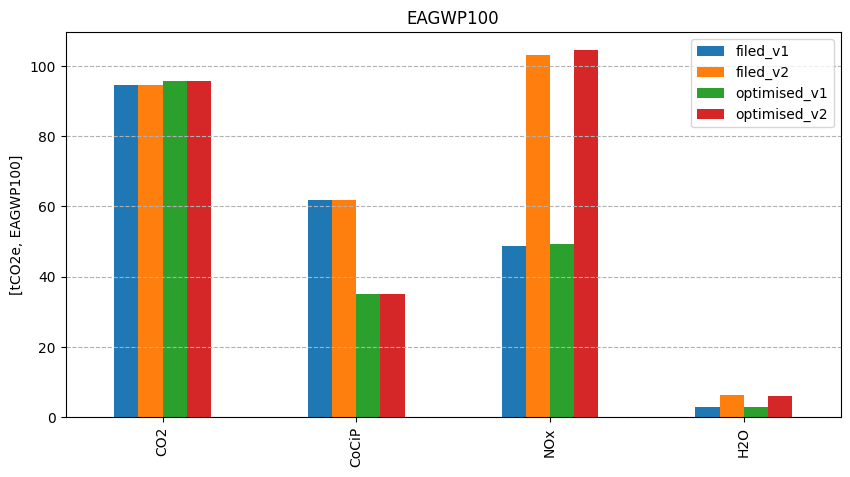

In [ ]:
plot_df = pd.concat([df1, df2, df3, df4], axis=1) / 1e3 # tons instead of kg
plot_df.plot(kind='bar', figsize=(10, 5))
plt.ylabel(f"[tCO2e, {metric}]")
plt.grid(axis="y", linestyle="--")
plt.title(f"{metric}")
# plt.savefig(f"../reports/20260709_{metric}.png", dpi=300, bbox_inches="tight")